## Import Required Libraries

In [10]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.stats.outliers_influence import variance_inflation_factor


## Load Dataset

In [11]:
df = pd.read_csv('Marketing_sales_data.csv')
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## Exploratory Data Analysis

In [12]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB


TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

## Visualize Relationships

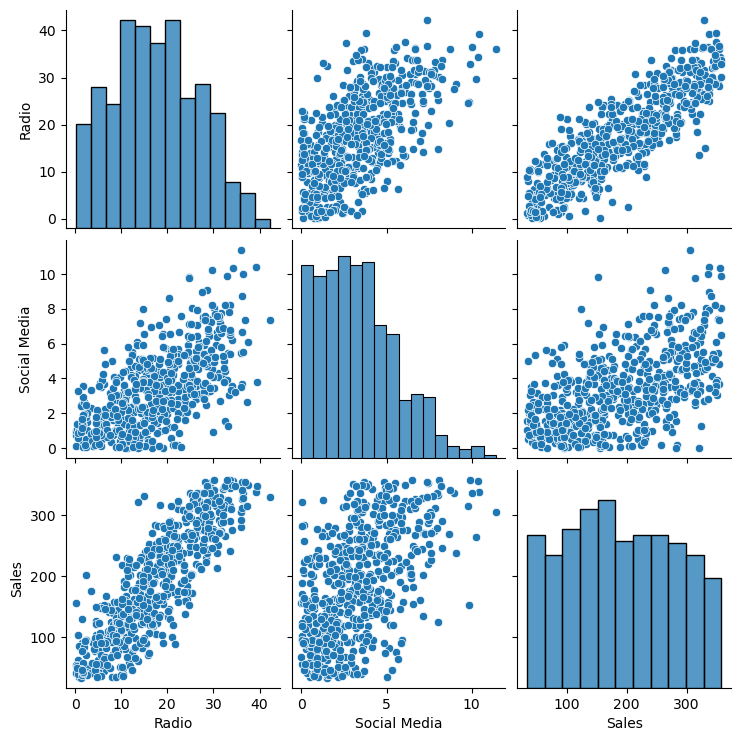

In [13]:
sns.pairplot(df)
plt.show()

## Check Multicollinearity

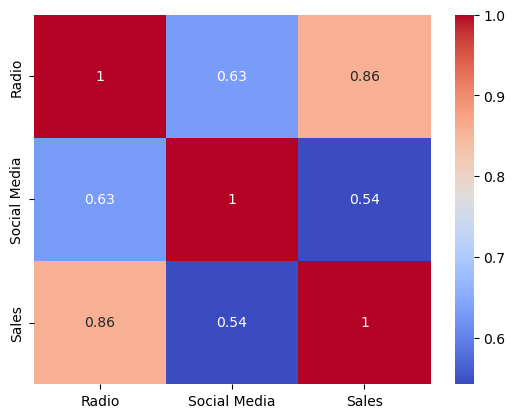

In [14]:
## correlation matrix

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Variance Inflation Factor

In [15]:
## using label encoder to convert categorical variables into numerical values
le_tv = LabelEncoder()
le_influencer = LabelEncoder()
df['TV'] = le_tv.fit_transform(df['TV'])
df["Influencer"] = le_influencer.fit_transform(df["Influencer"])
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,1,3.518070,2.293790,2,55.261284
1,1,7.756876,2.572287,1,67.574904
2,0,20.348988,1.227180,2,272.250108
3,2,20.108487,2.728374,1,195.102176
4,0,31.653200,7.776978,3,273.960377


In [16]:
## Using Variance Inflation Factor (VIF) to check for multicollinearity among the independent variables
x=df[['TV', 'Influencer', 'Social Media']].copy()
x['Intercept'] = 1
vif = pd.DataFrame()
vif["Feature"] = x.columns
vif["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif

,Feature,VIF
0,TV,1.075837
1,Influencer,1.002260
2,Social Media,1.073787
3,Intercept,8.611724


## Build Multiple Linear Regression Model

In [17]:
## Define x and y variables for regression analysis
x = df[['TV', 'Influencer', 'Social Media']]
y = df['Sales']

In [18]:
## Adding a constant to the independent variables for the regression model
x = sm.add_constant(x)

In [19]:
### Fitting the regression model
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     114.2
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           6.95e-58
Time:                        20:03:54   Log-Likelihood:                -3249.2
No. Observations:                 572   AIC:                             6506.
Df Residuals:                     568   BIC:                             6524.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          161.9033      8.732     18.542      0.000     144.753     179.054
TV             -33.2603      3.846     -8.648      0.000     -40.814     -25.706
Influencer       0.5086      2.681      0.190      0.850      -4.757       5.774
Social Media    18.6311      1.379     13.514      0.000      15.923      21.339
==============================================================================
Omnibus:                       43.649   Durbin-Watson:                   1.915
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.091
Skew:                          -0.281   Prob(JB):                     2.63e-05
Kurtosis:                       2.246   Cond. No.                         13.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Diagnostic plots for regression analysis

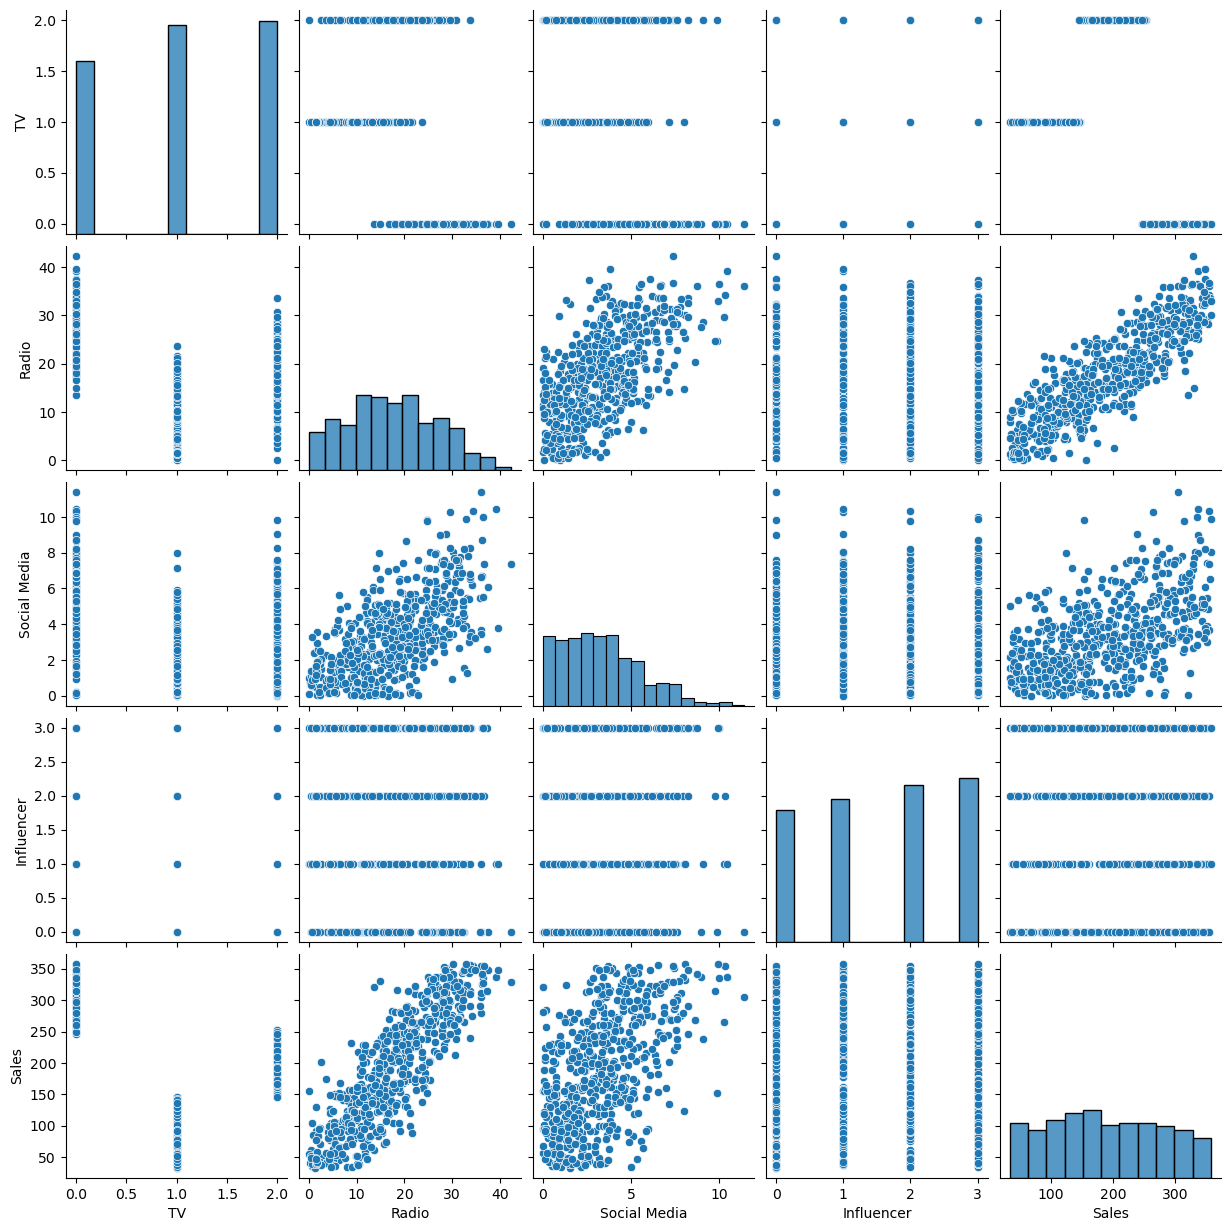

In [20]:
## Linearity 
sns.pairplot(df)

Text(0.5, 1.0, 'Residuals vs Fitted Values')

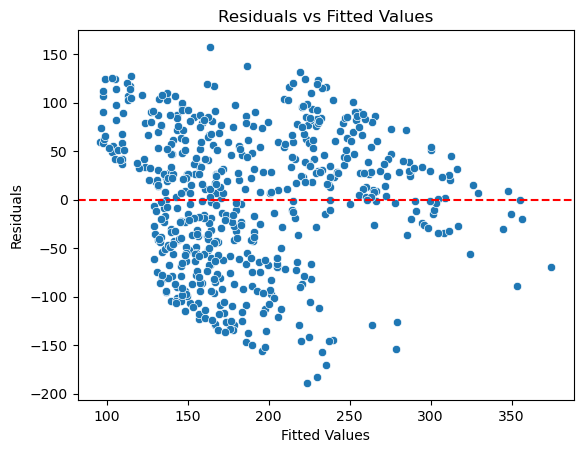

In [21]:
## Residual analysis
residuals = model.resid
fitted_values = model.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')


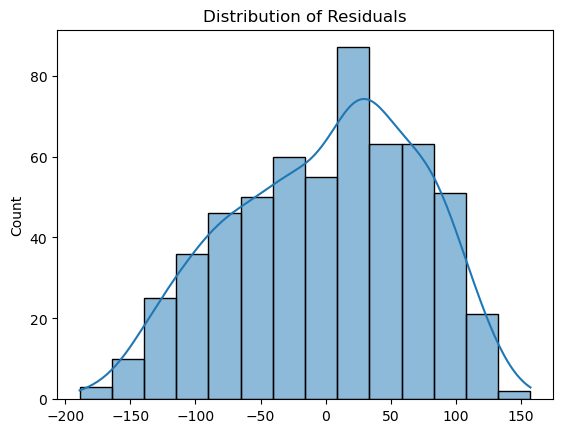

In [22]:
### Normality of residuals
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.show()

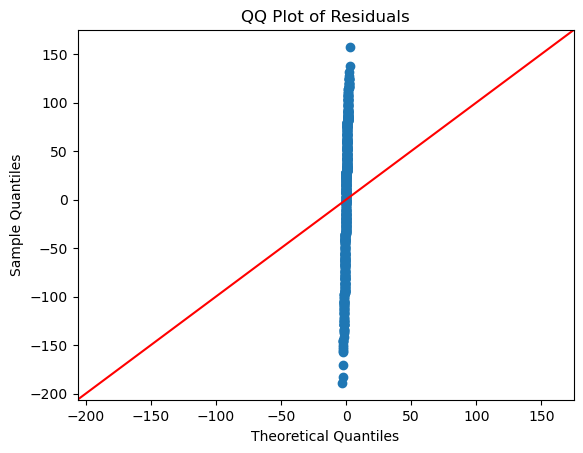

In [23]:
# QQ plot for normality
sm.qqplot(residuals, line='45')
plt.title('QQ Plot of Residuals')
plt.show()

In [24]:
## To check the coefficients of the model
print(model.params)

const           161.903269
TV              -33.260271
Influencer        0.508635
Social Media     18.631111
dtype: float64


##                              Coefficient Interpretation (Business Meaning)

Your model: Scales =161.903269−33.260271(TV)+0.508635(Influencer)+18.631111(Social Media)

                                                  TV (-33.260271)
Holding Influencer and Social Media constant, every 1-unit increase in TV advertising spend is associated with a decrease of approximately 33.26 units in Sales.


                                                Influencer (0.508635)

Holding other channels constant, every 1-unit increase in Influencer marketing spend increases Sales by approximately 0.51 units.


                                                 Social Media (18.631111)

Holding other channels constant, every 1-unit increase in Social Media spending increases Sales by approximately 18.63 units.


                                                 Intercept (161.903269)

When all marketing spends are zero, baseline Sales is approximately 161.9 units.

 ###                             <h1 style="font-size:40px;">Business Recommendation</h1>
Based on the regression analysis, marketing budget allocation should prioritize Social Media advertising, as it shows the strongest positive impact on Sales. Influencer marketing should be maintained at a moderate level as a supporting channel. However, TV advertising appears to have a negative relationship with Sales, suggesting inefficiencies in targeting or spending strategy. The company should reconsider or restructure TV campaigns before further investment.